# MODEL SELECTION IN CONTEXT AND USE

First of all, in the context of Oftacmology, the IA models can help a lot in the context of diagnosis, this statement think of the use of SR images more for complement for MEDIC INSTRUMENTATION, we cannot tell if the SR Images help better for IA models for they automaticly give diagnosos, following this idea, we will center on give the SR Image justifying this helps the subjetive doctor analysis, that COULD BE useful for later IA AUTOMATIC DIAGNOSIS, but this study is focus on SR Images and criteria above this concept. This doesnt mean we will not reach this topic, we can get to DL model for automatic diagnosisi complementing this devepment in SR. But that can be keep for later.Since now, we center on SR.

The criteria that we will be using will be based on another studies so we can build our own devepment with the best characteristics possible.
Once this noticed, we will determine the context and the needs of the MODEL ARCHITECTURE listed below:

## 1. **Input Resolution-Output Resolution:** 
Based on the dataset images, we can determinate the SR resolution just as and standart that works with the data flow proposed.

In [3]:
import cv2
img_r = r"E:\Proyects Python based\ProyectoAvanzado2\data\raw\M1\Aptos_messidor_dataset\Aptos_messidor_dataset\class_0\0a4e1a29ffff_aug_0.png"
img = cv2.imread(img_r)
print("The image resolution is: ",img.shape)

The image resolution is:  (512, 512, 3)


We can see that the example image have RGB channels and a squared shape of 512*512, who gives us the spected output

$$
\text{Input LR Image}
\;\rightarrow\;
\boxed{\text{Model}}
\;\rightarrow\;
\boxed{\text{OUTPUT}\;|\;512 \times 512}
$$

For the Input in LR, we can adjust at medical standars usually used that are *(2,4,8) so we will adjust this standar at our work.
To sumarize the information we will show  it below:

| Scale Factor | LR Resolution | Degradation Severity | Clinical / Industrial Interpretation |
|---|---|---|---|
| ×2 | 256×256 | Mild | Simulates hardware with a slight reduction in resolution. Minimal loss of microstructure. |
| ×4 | 128×128 | Moderate (Standard) | Realistic scenario in the SR literature. Significant loss of fine details (small vessels). |
| ×8 | 64×64 | Severe (Limit) | Extreme scenario to analyze hardware limits. High loss of spatial information. |

## 2. **Dedradation methods - selection and purpose:**

In order to keep building the model, we have to reach to degradation types and our selection, but this section is focused on explanation and understaning of those degradation models, also the explanation for what what models shoud be better for this project.

The ecuation based for generating  LR images form SR images is the following one:

$$ LR = D(HR) $$

Where D is the degradation procces, who re-defining we get a more universal form in the form shown above:

$$
\text{LR} = (\text{HR} \otimes k) \downarrow_s + n
$$

where:

- **HR**: original high-resolution image  
- **k**: blur kernel  
- **↓\_s**: downsampling operator with scale factor \(s\)  
- **n**: additive noise

To aboard this degradation we go back to our problem in context, since the retinal images  are obtained from cameras, we have to simulate  our procces of degradation thinking primarly in that. That already clarified, we can go back and check in the STATE-OF-ART review to check how is the dregradation selecion in cameras from medical usage. 

### **1. Downsampling methods:**
Downsampling means sub-register information of a certain nature, in this case, will be passing from 512*512 to lower resolutions.

### **Bilinear Interpolation**

Bilinear interpolation estimates the value of a new pixel using the weighted average of the four nearest neighboring pixels. It performs linear interpolation along both spatial axes.

$$
f(x,y)=
(1-\alpha)(1-\beta)Q_{11}
+\alpha(1-\beta)Q_{21}
+(1-\alpha)\beta Q_{12}
+\alpha\beta Q_{22}
$$

Where:

- $Q_{11}, Q_{21}, Q_{12}, Q_{22}$ are the four nearest neighboring pixels  
- $\alpha$ and $\beta$ are the relative distances along the horizontal and vertical axes  

**Characteristics:**

- Computationally efficient  
- Produces smooth transitions  
- May blur fine retinal details  

---

### **Bicubic Interpolation**

Bicubic interpolation uses the nearest **16 neighboring pixels** and applies cubic weighting functions to estimate the new intensity value.

$$
f(x,y)=\sum_{i=-1}^{2}\sum_{j=-1}^{2} w(i,j)\,I(x+i,y+j)
$$

Where:

- $I(x+i,y+j)$ are neighboring pixel intensities  
- $w(i,j)$ are cubic interpolation weights  

The cubic kernel is:

$$
w(t)=
\begin{cases}
(a+2)|t|^3-(a+3)|t|^2+1, & |t|<1 \\
a|t|^3-5a|t|^2+8a|t|-4a, & 1\le |t|<2 \\
0, & |t|\ge2
\end{cases}
$$

with:

$$
a=-0.5
$$

**Characteristics:**

- Standard baseline in Super-Resolution literature  
- Better edge preservation than bilinear interpolation  
- Produces realistic smooth degradation  

---

### **Lanczos Interpolation**

Lanczos interpolation uses a sinc-based kernel truncated by a finite window to preserve high-frequency information.

$$
L(x)=
\begin{cases}
\text{sinc}(x)\,\text{sinc}\left(\frac{x}{a}\right), & |x|<a \\
0, & |x|\ge a
\end{cases}
$$

Where:

$$
\text{sinc}(x)=\frac{\sin(\pi x)}{\pi x}
$$

and $a$ is the window size (typically $a=3$).

**Characteristics:**

- Preserves fine structures and edges  
- Maintains high-frequency detail  
- May introduce ringing artifacts  

---

### Practical Interpretation for Retinal Imaging

- **Bilinear** simulates smoother low-resolution acquisition  
- **Bicubic** is the standard reference method for SR training  
- **Lanczos** better preserves structural retinal details

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
img = np.array([
    [ 50, 100, 150, 200],
    [ 60, 110, 160, 210],
    [ 70, 120, 170, 220],
    [ 80, 130, 180, 230]
], dtype=np.uint8)

print("Original 4x4 image:")
print(img)

Original 4x4 image:
[[ 50 100 150 200]
 [ 60 110 160 210]
 [ 70 120 170 220]
 [ 80 130 180 230]]


In [3]:
bilinear = cv2.resize(img, (2,2), interpolation=cv2.INTER_LINEAR)

print("Bilinear result:")
print(bilinear)

Bilinear result:
[[ 80 180]
 [100 200]]


In [4]:
bicubic = cv2.resize(img, (2,2), interpolation=cv2.INTER_CUBIC)

print("Bicubic result:")
print(bicubic)

Bicubic result:
[[ 74 184]
 [ 96 206]]


In [5]:
lanczos = cv2.resize(img, (2,2), interpolation=cv2.INTER_LANCZOS4)

print("Lanczos result:")
print(lanczos)

Lanczos result:
[[ 76 183]
 [ 97 204]]


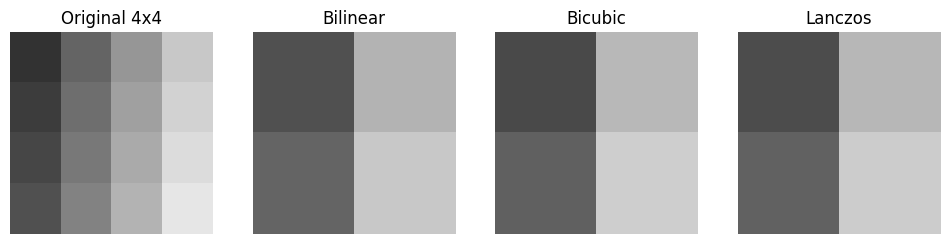

In [6]:
fig, axes = plt.subplots(1,4, figsize=(12,3))

titles = ['Original 4x4', 'Bilinear', 'Bicubic', 'Lanczos']
images = [img, bilinear, bicubic, lanczos]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.show()

## **2. Blur methods:**
Blur simulated, in the context of a camera, the movement,difraction, limitations in the lens and bad focalization. Following this idea, is necessary for us to add blur to our LR simulation image. 




---

### **Average Blur (Box Filter)**

Average blur replaces each pixel value with the arithmetic mean of its neighboring pixels inside a fixed window.

The operation is defined as:

$$
I'(x,y)=\frac{1}{K^2}\sum_{i=-k}^{k}\sum_{j=-k}^{k} I(x+i,y+j)
$$

Where:

- $I(x,y)$ is the original image  
- $I'(x,y)$ is the blurred image  
- $K$ is the kernel size  

For a kernel of size:

$$
K=2k+1
$$

A typical $3\times3$ kernel is:

$$
\frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

**Characteristics:**

- Simple smoothing  
- Reduces local intensity variations  
- Strongly removes fine details  

---

### **Gaussian Blur**

Gaussian blur applies weighted smoothing using a Gaussian kernel, giving higher importance to central pixels.

The Gaussian function is:

$$
G(x,y)=\frac{1}{2\pi\sigma^2}\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right)
$$

The blurred image is obtained by convolution:

$$
I'(x,y)=I(x,y)*G(x,y)
$$

Where:

- $\sigma$ controls blur intensity  

A Gaussian kernel preserves smoother transitions compared to average blur.

**Characteristics:**

- Most commonly used blur in Super-Resolution literature  
- Simulates optical blur realistically  
- Preserves natural image statistics  

---

### **Median Blur**

Median blur replaces each pixel with the median value inside a local neighborhood.

The operation is:

$$
I'(x,y)=\text{median}\{I(x+i,y+j)\}
$$

for all pixels inside the selected kernel.

For example, in a $3\times3$ neighborhood:

$$
\{12,14,15,16,18,19,20,21,200\}
$$

the median value becomes:

$$
18
$$

**Characteristics:**

- Effective against impulsive noise  
- Preserves edges better than average blur  
- Commonly used when salt-and-pepper artifacts are present  

---

### Practical Interpretation for Retinal Imaging

- **Average blur** simulates simple loss of local detail  
- **Gaussian blur** best approximates optical sensor degradation  
- **Median blur** useful when noise suppression is required before degradation analysis

## 3. **Noise Models for Image Degradation:**

Noise is commonly introduced during Low-Resolution (LR) generation to simulate sensor imperfections, electronic acquisition disturbances, and illumination variability. In retinal imaging, noise affects vessel visibility, lesion contrast, and small pathological structures that are important for diagnosis.

---

### **Gaussian Noise**

Gaussian noise adds random intensity variations following a normal distribution.

The noisy image is defined as:

$$
I'(x,y)=I(x,y)+n(x,y)
$$

Where:

$$
n(x,y)\sim \mathcal{N}(0,\sigma^2)
$$

and:

- $I(x,y)$ is the original image  
- $I'(x,y)$ is the noisy image  
- $\sigma$ controls the noise intensity  

The probability density function is:

$$
p(n)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{n^2}{2\sigma^2}\right)
$$

**Characteristics:**

- Most common synthetic noise model  
- Simulates sensor electronic fluctuations  
- Widely used in Super-Resolution literature  

---

### **Salt-and-Pepper Noise**

Salt-and-pepper noise randomly replaces pixels with extreme intensity values.

The noisy image becomes:

$$
I'(x,y)=
\begin{cases}
0, & \text{with probability } p_1 \\
255, & \text{with probability } p_2 \\
I(x,y), & \text{otherwise}
\end{cases}
$$

Where:

- 0 represents black pixels  
- 255 represents white pixels  

**Characteristics:**

- Simulates impulsive acquisition errors  
- Produces isolated bright and dark artifacts  
- Useful for robustness testing  

---

### **Poisson Noise**

Poisson noise models photon-counting fluctuations generated during image acquisition.

The noisy signal follows:

$$
I'(x,y)\sim \text{Poisson}(I(x,y))
$$

Its variance depends on the signal itself:

$$
Var(I)=E(I)
$$

Where:

- higher intensity values produce higher variance  

**Characteristics:**

- Physically related to photon acquisition processes  
- More realistic for low-light imaging  
- Signal-dependent noise  

---

### Practical Interpretation for Retinal Imaging

- **Gaussian noise** approximates electronic sensor noise  
- **Salt-and-pepper noise** simulates impulsive acquisition artifacts  
- **Poisson noise** approximates photon-counting variability in optical systems

# **MODEL SELECTION CONCLUSIONS:**

For this desition, we can think as a physicist, the images obtain using cameras, in the real world, works like this, first of all, the image get through the lens, we can read this as the blur, because of the limitations of the device lens, later, this blur image goes trough discretization, where the reoslution of the image is given, and the las stage of this procces would be the noise, this is caused by electronic and maybe bad read  of disretization.

In this order of ideas, our flux would look like this:

 IMAGE --> LENS(BLUR)--->DISCRETIZATION(DOWNSAMPLING)--->ELECTRONIC(NOISE)->LR

My personal objetive is to add all the real scenarios of imaging, to develop and cuantize where scenario is better, but we cant select every kind of degradation to a new model train, this would be computationally expensive, so we will select the scenarios more accurate, also remebering that we are going to use *2,4,8 downsampling. so we gotta be carful with how many models we can train.

In this sense, we are going to build 3 scenarios,a robust, a medium, and a common scenario. This way we can actually tell what model is doing better and how the sensor would work is is not selected yet.

Based on papers primarly, we are doing:
## Proposed Experimental Degradation Scenarios

| Scenario | Downsampling Method | Blur Type | Noise Type | Objective |
|----------|---------------------|-----------|------------|-----------|
| A | Bicubic | Gaussian ($\sigma = 1.0$) | Gaussian ($\sigma_n = 5$) | Standard baseline commonly used in Super-Resolution literature |
| B | Bilinear | Gaussian ($\sigma = 1.5$) | Gaussian ($\sigma_n = 10$) | Simulation of moderate-quality acquisition systems |
| C | Lanczos | Gaussian ($\sigma = 2.0$) | Poisson | Evaluation under strong degradation and sensor variability |

But now we have a problem, we have to train 3 scenarios for all 3 LR images. this could be a problem if we dont have enoght computation capacity, but this way we can justify the use of APOLO, the clusterof EAFIT for solving all this scenarios and obtain details  of every model and their functioning.

## Complete Experimental Training Design

| Model | Scenario | Downsampling Method | Blur Type | Noise Type | Scale Factor | LR Size |
|-------|----------|---------------------|-----------|------------|--------------|---------|
| Model 1 | A | Bicubic | Gaussian ($\sigma = 1.0$) | Gaussian ($\sigma_n = 5$) | ×2 | 256×256 |
| Model 2 | A | Bicubic | Gaussian ($\sigma = 1.0$) | Gaussian ($\sigma_n = 5$) | ×4 | 128×128 |
| Model 3 | A | Bicubic | Gaussian ($\sigma = 1.0$) | Gaussian ($\sigma_n = 5$) | ×8 | 64×64 |
| Model 4 | B | Bilinear | Gaussian ($\sigma = 1.5$) | Gaussian ($\sigma_n = 10$) | ×2 | 256×256 |
| Model 5 | B | Bilinear | Gaussian ($\sigma = 1.5$) | Gaussian ($\sigma_n = 10$) | ×4 | 128×128 |
| Model 6 | B | Bilinear | Gaussian ($\sigma = 1.5$) | Gaussian ($\sigma_n = 10$) | ×8 | 64×64 |
| Model 7 | C | Lanczos | Gaussian ($\sigma = 2.0$) | Poisson | ×2 | 256×256 |
| Model 8 | C | Lanczos | Gaussian ($\sigma = 2.0$) | Poisson | ×4 | 128×128 |
| Model 9 | C | Lanczos | Gaussian ($\sigma = 2.0$) | Poisson | ×8 | 64×64 |

## Experimental Design Rationale

The definition of multiple degradation scenarios and scaling factors enables a broader evaluation of the Super-Resolution model under diverse acquisition conditions. By training independent models across different combinations of interpolation methods, blur intensity, noise distributions, and resolution factors, it becomes possible to analyze the robustness of the proposed SRGAN under realistic image formation variations.

This experimental design also provides practical value beyond model comparison. Since each degradation scenario approximates different sensor behaviors and acquisition qualities, the resulting performance analysis may help identify which type of imaging sensor or acquisition condition is more compatible with the Super-Resolution framework being developed.

In an applied context, this means that if deployment constraints require selecting a specific acquisition system, the experimental results can serve as a reference to determine which sensor characteristics are more likely to preserve sufficient information for successful reconstruction through the proposed SRGAN model.